#  1. SET UP AND LOAD DATA

+ Upload các file train_x, train_y lên google colab (2 file này có kích thước không quá lớn nên sẽ upload không quá lâu)

In [ ]:
!pip install tensorflow opencv-python matplotlib

In [ ]:
from zipfile import ZipFile
with ZipFile('/content/public_test.zip','r') as zipObj:
  zipObj.extractall()

In [ ]:
with ZipFile('/content/train.zip','r') as zipObj:
  zipObj.extractall()

In [ ]:
with ZipFile('/content/private_test.zip','r') as zipObj:
  zipObj.extractall()

# 2. PRE-PROCESSING DATA

In [ ]:
import tensorflow as tf
import os
import cv2
import imghdr
from matplotlib import pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization

<ipython-input-4-c6f97f5e8dea>:4: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


In [ ]:
import pandas as pd
df = pd.read_csv('X_train.csv')
df.isnull().sum()
#df.head()

,0
cat1,0
num7,0
num1,0
num2,0
num8,0
cat2,0
cat3,0
cat4,0
cat5,0
num3,0


In [ ]:
from math import nan
df=df.fillna(df.mean())
x_train = df

y_train = pd.read_csv("y_train.csv")
if len(x_train) == len(y_train):
    x_train["Answer"] = y_train.iloc[:, 0]  # Lấy cột đầu tiên của y_train
    x_train.to_csv("train_data.csv", index=False)

In [ ]:
df = pd.read_csv('train_data.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17479 entries, 0 to 17478
Data columns (total 21 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   cat1    17479 non-null  int64  
 1   num7    17479 non-null  float64
 2   num1    17479 non-null  float64
 3   num2    17479 non-null  float64
 4   num8    17479 non-null  float64
 5   cat2    17479 non-null  int64  
 6   cat3    17479 non-null  int64  
 7   cat4    17479 non-null  int64  
 8   cat5    17479 non-null  int64  
 9   num3    17479 non-null  float64
 10  num4    17479 non-null  float64
 11  cat6    17479 non-null  int64  
 12  cat7    17479 non-null  int64  
 13  cat8    17479 non-null  int64  
 14  num9    17479 non-null  float64
 15  num10   17479 non-null  float64
 16  num5    17479 non-null  float64
 17  num6    17479 non-null  float64
 18  num11   17479 non-null  float64
 19  num12   17479 non-null  float64
 20  Answer  17479 non-null  float64
dtypes: float64(13), int64(8)
memory usa

<Axes: >

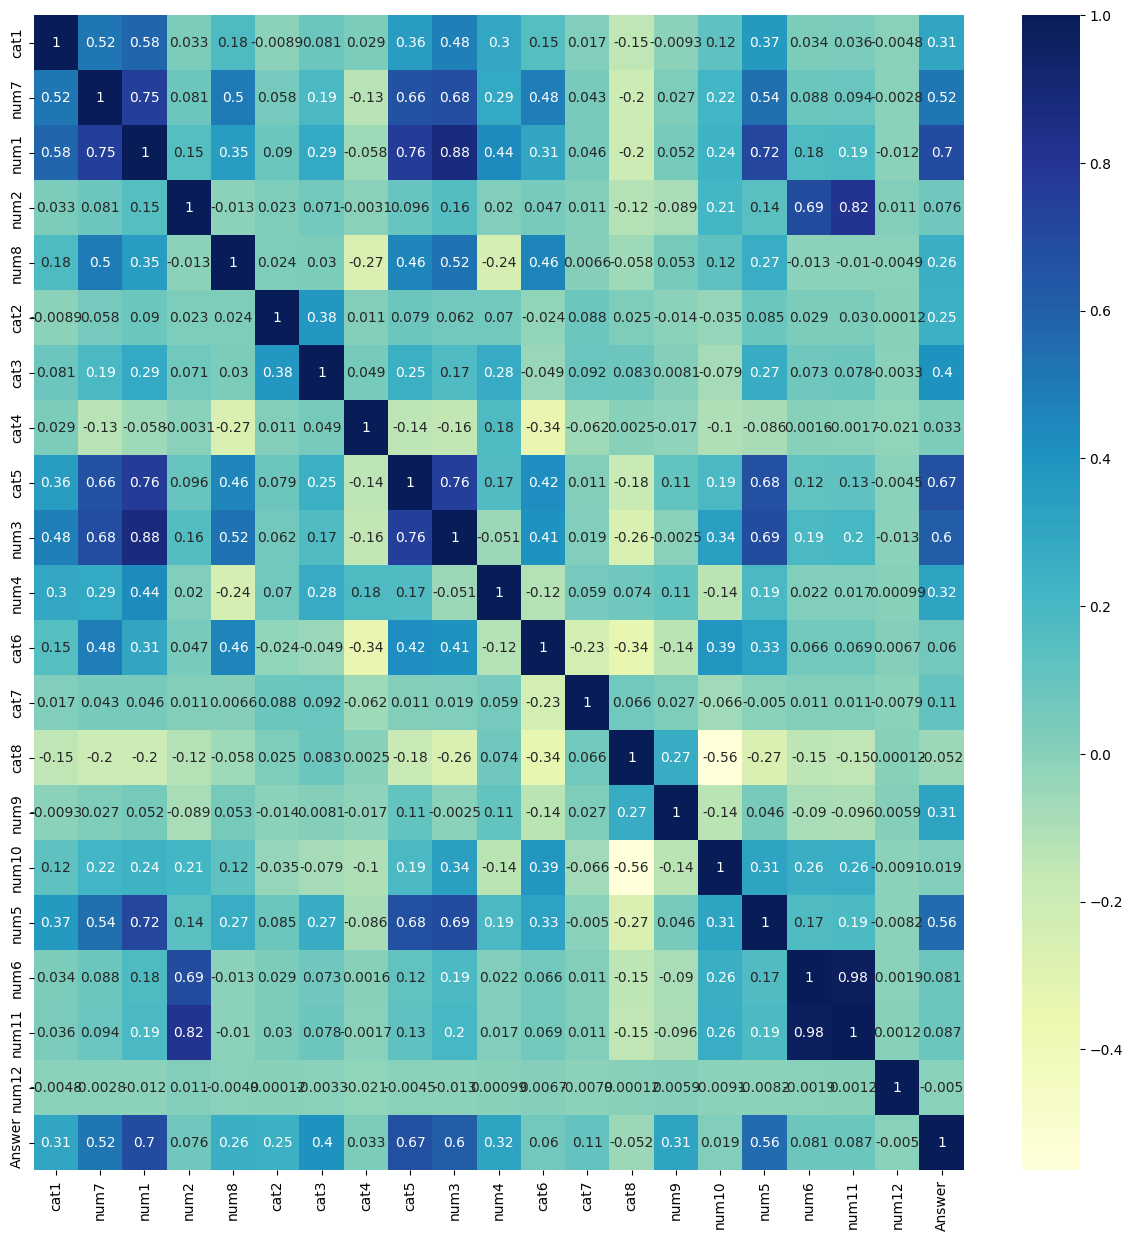

In [ ]:
import seaborn as sns
plt.figure(figsize=(15,15))
sns.heatmap(df.corr(), annot=True, cmap='YlGnBu')

# **3. TRAIN**

+ Team đã sử dụng thử rất nhiều model khác nhau nhưng ưu tiên sử dụng model **Random Forest và XGBoost**

In [ ]:

features = ['cat1',	'num7','num1','num2','num8','cat2','cat3','cat4','cat5','num3','num4','cat6','cat7'	,'cat8'	,'num9'	,'num10'	,'num5'	,'num6'	,'num11','num12'	]
# features tat ca cac o
data = df
X = data[features]
y = data['Answer']
y.head()

,Answer
0,531.0
1,265.0
2,336.0
3,350.0
4,480.0


# **SPLIT DATA**

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(X, y, train_size=0.7,test_size=0.3, random_state=42)

# **DECISION TREE**

In [ ]:
from sklearn.tree import DecisionTreeRegressor
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [ ]:
pd.DataFrame({'y': y_valid.head(), 'y_preds': dt_model.predict(X_valid.head())})

,y,y_preds
14611,715.0,512.5
16440,2700.0,1000.0
247,568.0,505.0
17294,760.0,875.0
4618,975.0,957.5


# **RANDOM FOREST**
+ Tối ưu hoá model bằng các parameters

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
pd.DataFrame({'y': y_valid.head(), 'y_preds': rf_model.predict(X_valid.head())})

,y,y_preds
14611,715.0,508.24510
16440,2700.0,2159.60050
247,568.0,623.20600
17294,760.0,759.36825
4618,975.0,1064.74700


In [ ]:
params ={
    'n_estimators': [1,20,50,100,200],
    'max_depth': [10,20,30],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4]
}

In [ ]:
from sklearn.model_selection import GridSearchCV
grid_search_rf = GridSearchCV(estimator=rf_model, param_grid=params, cv=3, n_jobs=-1,scoring='neg_mean_squared_error')
grid_search_rf.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [1, 20, 50, 100, 200, 300]},
             scoring='neg_mean_squared_error')

In [ ]:
pd.DataFrame({'y': y_valid.head(), 'y_preds': grid_search_rf.predict(X_valid.head())})

,y,y_preds
14611,715.0,505.656410
16440,2700.0,2234.963300
247,568.0,629.263565
17294,760.0,758.005375
4618,975.0,1072.818645


# **GRADIENT BOOSTING**

In [ ]:
from sklearn.ensemble import  GradientBoostingRegressor
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [ ]:
params_grid= {
    'n_estimators': [5,10,20,50,100],
    'learning_rate': [0.1,0.2,0.3]
}

In [ ]:
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(estimator=gb_model, param_grid=params_grid, cv=3)
grid_search.fit(X_train, y_train)

KeyboardInterrupt: 

In [ ]:
pd.DataFrame({'y': y_valid.head(), 'y_preds': gb_model.predict(X_valid.head())})

,y,y_preds
14611,715.0,597.509197
16440,2700.0,2294.450643
247,568.0,593.221103
17294,760.0,646.596449
4618,975.0,988.094880


In [ ]:
pd.DataFrame({'y': y_valid.head(), 'y_preds': grid_search.predict(X_valid.head())})

,y,y_preds
14611,715.0,593.853999
16440,2700.0,2180.244839
247,568.0,577.458329
17294,760.0,667.443548
4618,975.0,951.228989


# **XGBOOST**
+ Tối ưu hoá model bằng các parameters

In [ ]:
from math import nan
params_xgboost ={
    'missing' : [nan],
    'n_estimators': [20,50,100],
    'learning_rate': [0.1,0.2,0.3],

}

In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
xgb_model = xgb.XGBRegressor(random_state=42, n_estimators=100)
grid_search_xg = GridSearchCV(estimator=xgb_model, param_grid=params_xgboost, cv=3, n_jobs=-1)
grid_search_xg.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, m...one,
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=100,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=42, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.1, 0.2, 0.3], 'missing': [nan],
                         'n_estimators': [20, 50, 100]})

In [ ]:
pd.DataFrame({'y': y_valid.head(), 'y_preds': grid_search_xg.predict(X_valid.head())})

,y,y_preds
14611,715.0,524.233948
16440,2700.0,2149.178467
247,568.0,566.402100
17294,760.0,696.392822
4618,975.0,1009.421753


# **4. DỰ ĐOÁN KẾT QUẢ TỪ FILE TEST**
+ Fill những phần trống bằng các giá trị mean của data để model có thể dự đoán chính xác

In [ ]:
df_public = pd.read_csv('X_private_test.csv')
df_public = df_public.fillna(df_public.mean())
y_pred = grid_search_rf.predict(df_public)
df_predictions = pd.DataFrame({"wear_rate": y_pred})
df_predictions.to_csv("predictions.csv", index=False)

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- num12


In [ ]:
import zipfile
with zipfile.ZipFile("prediction.zip", "w", zipfile.ZIP_DEFLATED) as zipf:
    zipf.write("predictions.csv")

In [ ]:
ans = pd.read_csv('predictions.csv')
ans.head()

,wear_rate
0,335.639070
1,226.585107
2,1850.448750
3,600.707675
4,983.879950
